### Import necessary libraries

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import re
import numpy as np

from matplotlib_venn import venn3
from ast import literal_eval

### Import dataset and a first look

In [2]:
df_games = pd.read_csv("datasets/games_march2025.csv")

df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89618 entries, 0 to 89617
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   appid                     89618 non-null  int64  
 1   name                      89618 non-null  object 
 2   release_date              89618 non-null  object 
 3   required_age              89618 non-null  int64  
 4   price                     89618 non-null  float64
 5   dlc_count                 89618 non-null  int64  
 6   detailed_description      89421 non-null  object 
 7   about_the_game            89398 non-null  object 
 8   short_description         89498 non-null  object 
 9   reviews                   10401 non-null  object 
 10  header_image              89618 non-null  object 
 11  website                   41114 non-null  object 
 12  support_url               44110 non-null  object 
 13  support_email             78798 non-null  object 
 14  window

In [3]:
# Summary of statistics for numerical attributes
df_games.describe()

,appid,required_age,price,dlc_count,metacritic_score,achievements,recommendations,user_score,score_rank,positive,...,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
count,8.961800e+04,89618.000000,89618.000000,89618.000000,89618.000000,89618.000000,8.961800e+04,89618.000000,39.000000,8.961800e+04,...,8.961800e+04,89618.000000,8.961800e+04,89618.000000,89618.000000,8.961800e+04,89618.000000,8.961800e+04,89618.000000,89618.000000
mean,1.656904e+06,0.183624,7.309623,0.595583,2.903245,20.552333,1.009401e+03,0.032817,99.128205,1.269896e+03,...,1.149119e+02,5.032694,1.147559e+02,5.301814,4.558627,9.833994e+01,45.352418,1.315490e+03,5.231639,15.584581
std,9.168390e+05,1.725594,13.331073,15.351920,14.445358,163.562418,2.204815e+04,1.615149,0.695076,3.181441e+04,...,6.814748e+03,181.100334,8.806711e+03,189.591095,16.538036,5.717544e+03,40.685695,3.542370e+04,22.335358,444.277307
min,2.000000e+01,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,98.000000,0.000000e+00,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,-1.000000,-1.000000e+00,-1.000000,-1.000000
25%,8.550525e+05,0.000000,0.990000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,99.000000,1.000000e+00,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,-1.000000,-1.000000e+00,-1.000000,-1.000000
50%,1.524730e+06,0.000000,4.990000,0.000000,0.000000,5.000000,0.000000e+00,0.000000,99.000000,1.000000e+01,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,60.000000,1.500000e+01,-1.000000,-1.000000
75%,2.430852e+06,0.000000,9.990000,0.000000,0.000000,20.000000,0.000000e+00,0.000000,100.000000,5.800000e+01,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,84.000000,8.100000e+01,-1.000000,-1.000000
max,3.542350e+06,21.000000,999.980000,3427.000000,97.000000,9821.000000,4.401572e+06,100.000000,100.000000,7.480813e+06,...,1.462997e+06,18568.000000,1.462997e+06,18568.000000,100.000000,1.212356e+06,100.000000,8.632939e+06,100.000000,96473.000000


In [4]:
# Summary of statistics for categorical attributes
df_games.describe(include='object')

,name,release_date,detailed_description,about_the_game,short_description,reviews,header_image,website,support_url,support_email,...,full_audio_languages,packages,developers,publishers,categories,genres,screenshots,movies,estimated_owners,tags
count,89618,89618,89421,89398,89498,10401,89618,41114,44110,78798,...,89618,89618,89618,89618,89618,89618,89618,89618,89618,89618
unique,88899,4459,89075,89040,88586,10291,89587,33321,29309,48174,...,2882,75740,56478,49798,7471,2689,89482,87183,15,70420
top,Alone,2024-10-31,Help the beautiful girls to immerse themselves...,Help the beautiful girls to immerse themselves...,Find the objects that are hidden on the map.,“ ” Read more on PC Gamer,https://shared.akamai.steamstatic.com/store_it...,https://www.facebook.com/8FloorGames/,https://www.facebook.com/8FloorGames,info@bigfishgames.com,...,[],[],[],[],"['Single-player', 'Family Sharing']","['Casual', 'Indie']",[],[],0 - 20000,[]
freq,6,141,58,58,50,21,5,247,270,314,...,49823,13819,221,547,19088,5099,106,2411,59320,16872


In [5]:
df_games.head()

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,771,7101,74,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517
4,359550,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,3.99,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",NaN,...,682,2434,306,80,89916,"{'FPS': 9831, 'PvP': 9162, 'e-sports': 9072, '...",84,1168020,76,12608


A preliminary check shows that some numeric columns contain -1 as value, for the benefit of analysis, these values are replaced by value 0

In [ ]:
# Replace all scalar -1 values with 0 in the dataframe
df_games = df_games.replace(-1, 0)

### Dealing with null value
A *percentage stacked bar chart* of non-null values in the dataset<br>

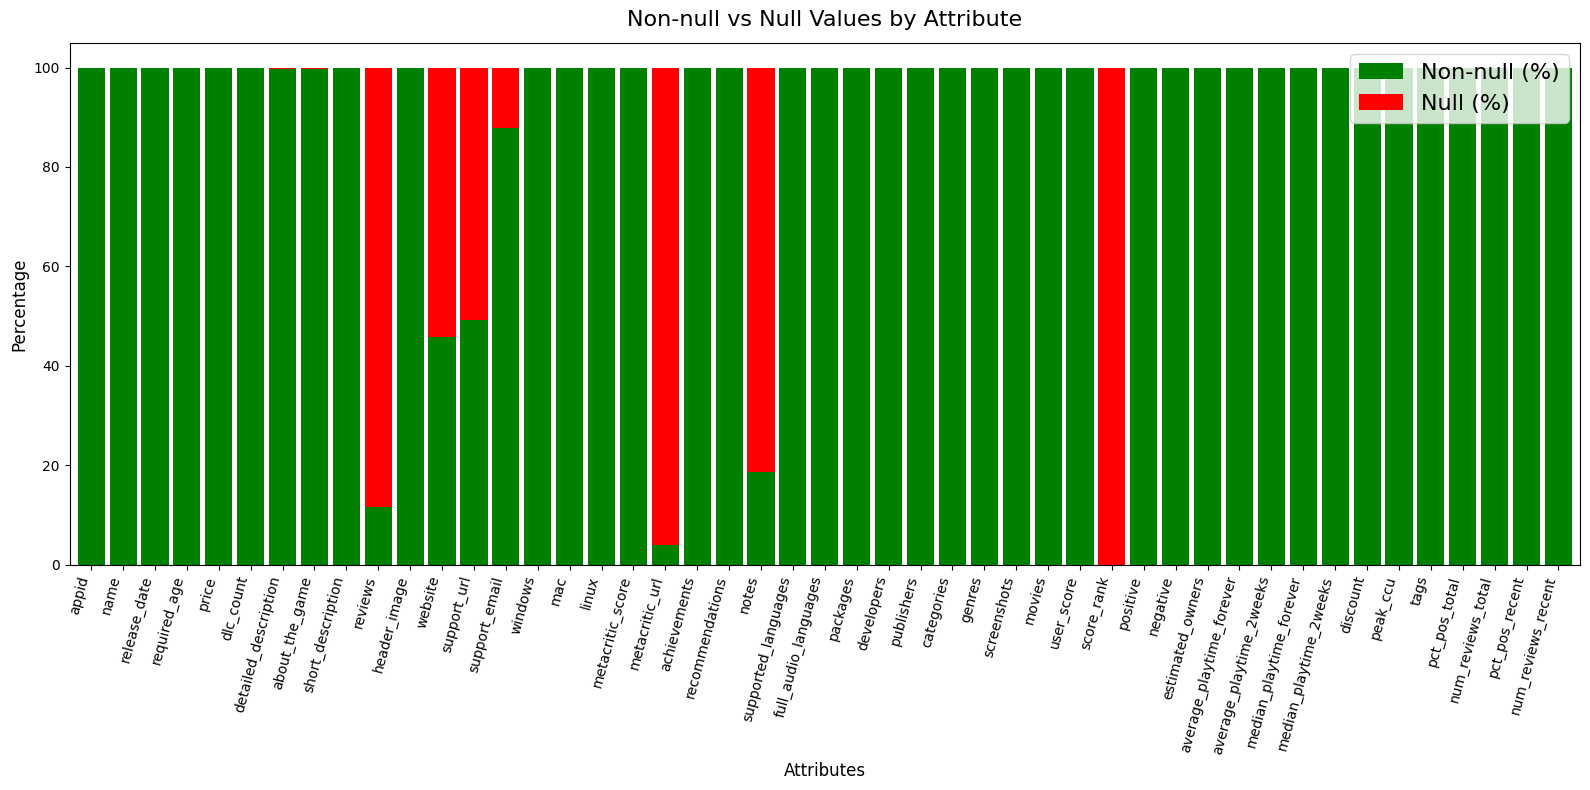

In [6]:
null_pct = df_games.isna().mean() * 100
non_null_pct = 100 - null_pct

plot_null = pd.DataFrame({
    'Non-null (%)': non_null_pct,
    'Null (%)': null_pct
})

ax = plot_null.plot(
    kind='bar',
    stacked=True,
    figsize=(16, 8),
    color=['green', 'red'],
    width=0.85
)

ax.set_ylabel('Percentage', fontsize=12)
ax.set_xlabel('Attributes', fontsize=12)
ax.set_title('Non-null vs Null Values by Attribute', fontsize=16, pad=12)
ax.legend(loc='upper right', fontsize=16)
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()

After the visualization, the following attributes will be excluded from the subsequent elaboration due to high percentage of null values:<br>
1. reviews
2. metascritic_url
3. notes
4. score_rank

In [7]:
df_games = df_games.drop(['reviews', 'metacritic_url', 'notes', 'score_rank'], axis=1)

### Dropping attributes that are not relevant for the analysis
Th attributes that are being dropped are of three categories:<br>
1. attributes containing URLs 
2. attributes containing descriptions
3. attributes redundant and conatins information related to recent event which are not relevant for the overall analysis

In [8]:
# Drop columns containing URLs, images, and contact info which are not relevant for analysis
df_games = df_games.drop(['website', 'support_url', 'header_image', 'support_email', 'screenshots', 'movies'], axis=1)

# Drop long text fields that are not useful for analysis and may contain a lot of noise
df_games = df_games.drop(['detailed_description', 'about_the_game', 'short_description', 'packages'], axis=1)

# Drop columns related to recent playtime and reviews which may not be relevant for the overall analysis of the games
df_games = df_games.drop(['median_playtime_2weeks', 'average_playtime_2weeks', 'pct_pos_recent', 'num_reviews_recent'], axis=1)

### *supported_languages* and *full_audio_languages* cleaning

In [10]:
# Serialize the supported_languages column by splitting the comma-separated values and exploding the list into individual rows
langs_series = df_games['supported_languages'].fillna('missing').str.split(',').explode().str.strip()

# Clean the langs_series by replacing malformed entries
langs_series = langs_series.str.replace(r'^\s+', '', regex=True)  # Remove leading whitespace
langs_series = langs_series.str.replace(r'\s+$', '', regex=True)  # Remove trailing whitespace
langs_series = langs_series.str.replace(r"[' \"]", '', regex=True)  # Remove quotes
langs_series = langs_series.str.replace(r'[\[\]]', '', regex=True)  # Remove square brackets
langs_series = langs_series.str.replace(r'b/b', '', regex=True)  # Remove b/b artifacts
langs_series = langs_series.str.replace(r'\\r\\n', '', regex=True)  # Remove \r\n

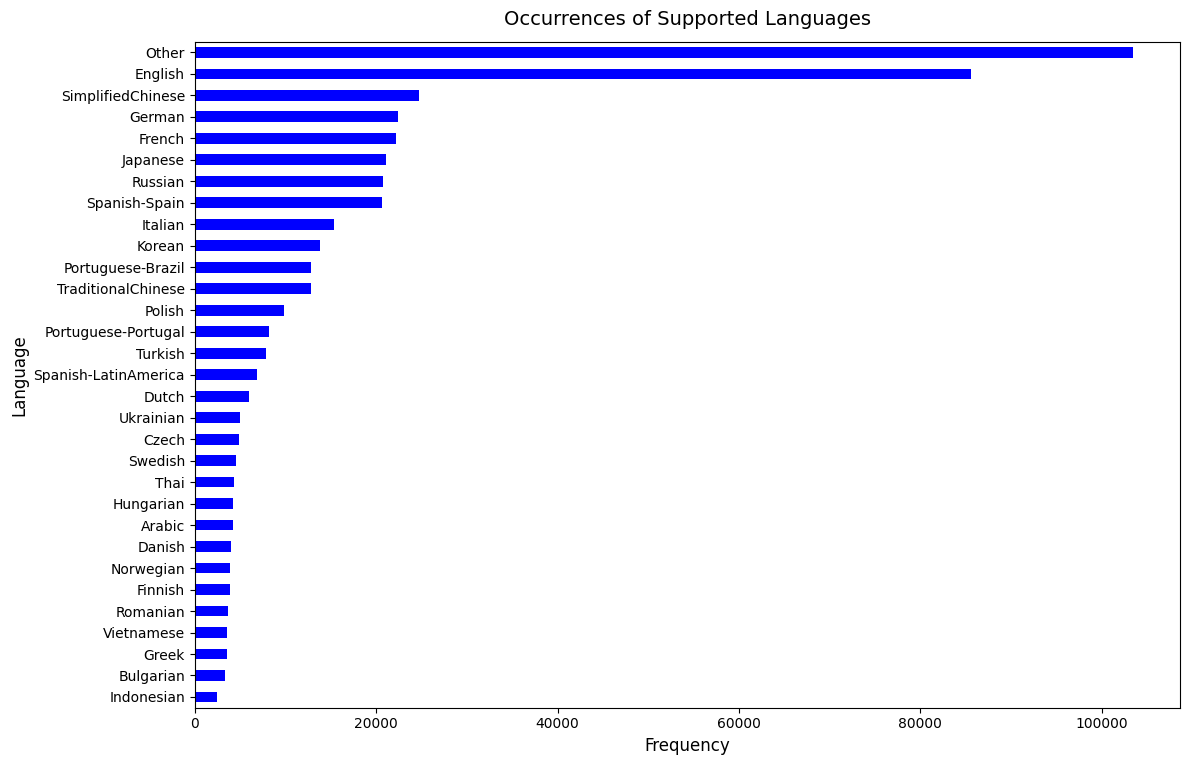

In [11]:
# Count occurrences of each language
lang_counts = langs_series.value_counts().sort_values(ascending=False)
max_bars = 30
if len(lang_counts) > max_bars:
    top = lang_counts.head(max_bars).copy()
    top['Other'] = lang_counts.iloc[max_bars:].sum()
else:
    top = lang_counts.copy()
# Create horizontal bar chart

ax = top.sort_values().plot(
    kind='barh',
    figsize=(12, max(6, 0.25 * len(top))),
    color='blue'
)
ax.set_xlabel('Frequency', fontsize=12)
ax.set_ylabel('Language', fontsize=12)
ax.set_title('Occurrences of Supported Languages', fontsize=14, pad=12)

plt.tight_layout()
plt.show()

Both *support_languages* and *full_audio_languages* will be used as a metric for evaluate user accessibility.<br>
However, because the large number of different languages are present in the dataset and we are more interested in assessing how many languages does a game support instead of how many games support a certain language, 2 new columns containing the count of supported languages are added and the original ones are dropped<br>

In [12]:
# Add a column with the number of supported languages per item
df_games['num_supported_languages'] = df_games['supported_languages'].fillna('').astype(str).map(lambda s: 0 if s.strip().lower() in ['', 'missing'] else len([p for p in s.split(',') if p.strip()]))

# Add a column with the number of audio languages per item
df_games['num_audio_languages'] = df_games['full_audio_languages'].fillna('').astype(str).map(lambda s: 0 if s.strip().lower() in ['', 'missing'] else len([p for p in s.split(',') if p.strip()]))

# Drop the original language columns since we now have the counts
df_games = df_games.drop(['supported_languages', 'full_audio_languages'], axis=1)

### *tags*, *categories*, and *genres* attributes intersection
A preliminary check at the three analyzed attribute show that almost of *genres*'s value can be found under *tags* therefore creating a redundancy; while *categories* shows only a small overlap with *tags*, a further checks shows that more than half of its values (like "commentary available", "Family sharing", "Steam Achievements" and so on) are not interesting for the purpose of this project, and others differ only in spelling, for example, "single player" in *categories* and "singleplayer" in *tags*.<br>
As a consequence, the *categories* and *genres* attributes are deemed redundant, and therefore dropped.

In [13]:
# A quick check of the first row of the tags, categories, and genres columns to understand their structure
print(df_games['tags'].iloc[0])
print(df_games['categories'].iloc[0])
print(df_games['genres'].iloc[0])

print(type(df_games['tags'].iloc[0]))
print(type(df_games['categories'].iloc[0]))
print(type(df_games['genres'].iloc[0]))

{'FPS': 90857, 'Shooter': 65397, 'Multiplayer': 62332, 'Competitive': 53359, 'Action': 47512, 'Team-Based': 46430, 'e-sports': 43533, 'Tactical': 41354, 'First-Person': 39414, 'PvP': 34470, 'Online Co-Op': 33966, 'Co-op': 30263, 'Strategy': 30111, 'Military': 28699, 'War': 28006, 'Difficult': 25966, 'Trading': 25717, 'Realistic': 25430, 'Fast-Paced': 25318, 'Moddable': 6603}
['Multi-player', 'Cross-Platform Multiplayer', 'Steam Trading Cards', 'Steam Workshop', 'In-App Purchases', 'Valve Anti-Cheat enabled', 'Stats', 'Remote Play on Phone', 'Remote Play on Tablet', 'Remote Play on TV', 'Steam Timeline']
['Action', 'Free To Play']
<class 'str'>
<class 'str'>
<class 'str'>


In [14]:
# Define a normalization helper function to normalize strings for consistent comparison and analysis
def normalize_key(key):
    key = str(key).lower().strip()  # Convert to string, lowercase, and trim whitespace
    key = re.sub(r"[^a-z0-9]+", "_", key)  # Replace non-alphanumeric sequences with '_'
    key = key.strip("_")  # Remove leading/trailing underscores
    return key

In [15]:
# Define a function to normalize the 'tags' column, which contains string representations of dictionaries
def normalize_dict(x):
    if pd.isna(x):
        return {}

    parsed = literal_eval(str(x))

    # Convert empty lists to empty dictionaries
    # The column initially contains string representations of dictionaries, but some entries are empty lists instead of empty dictionaries
    if isinstance(parsed, list):
        if len(parsed) == 0:
            return {}
        else:
            raise ValueError(f"Unexpected non-empty list: {parsed}")

    if isinstance(parsed, dict):
        return {normalize_key(k): v for k, v in parsed.items()}

    raise ValueError(f"Unexpected type: {type(parsed)}")


# Normalize the entire column
df_games["tags"] = df_games["tags"].apply(normalize_dict)

# Extract all unique normalized keys
tags_unique = sorted({key for d in df_games["tags"] for key in d.keys()})

In [16]:
# Analogously, define a function to normalize the list type columns (categories and genres), which contains string representations of lists
def normalize_list(x):
    if pd.isna(x):
        return []

    parsed = literal_eval(str(x))

    if isinstance(parsed, list):
        return [normalize_key(item) for item in parsed]

    raise ValueError(f"Expected a list, got {type(parsed)}")


# Normalize the entire column
df_games["categories"] = df_games["categories"].apply(normalize_list)

# Extract all unique normalized values
categories_unique = sorted({value for lst in df_games["categories"] for value in lst})

In [17]:
# Normalize the genres column and extract unique normalized values
df_games['genres'] = df_games['genres'].apply(normalize_list)

# Extract all unique normalized values
genres_unique = sorted({value for lst in df_games['genres'] for value in lst})

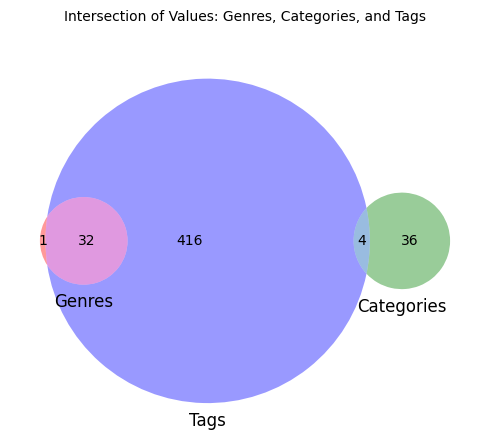

In [18]:
# Convert lists of unique values to sets for Venn diagram
genres_set = set(genres_unique)
categories_set = set(categories_unique)
tags_set = set(tags_unique)

# Create Venn diagram
plt.figure(figsize=(5, 5))
venn3([genres_set, categories_set, tags_set], 
      set_labels=('Genres', 'Categories', 'Tags'))
plt.title('Intersection of Values: Genres, Categories, and Tags', fontsize=10, pad=20)
plt.tight_layout()
plt.show()

In [19]:
df_games = df_games.drop(['categories', 'genres'], axis=1)

### System compatibility check *windows*, *linux* and *mac*
The three attributes signals wether the game is available on different operating systems.<br>
The resulting bar chart shows that all games support windows os, while the other two has more variance. The *windows* attribute is dropped for it provides no additional information

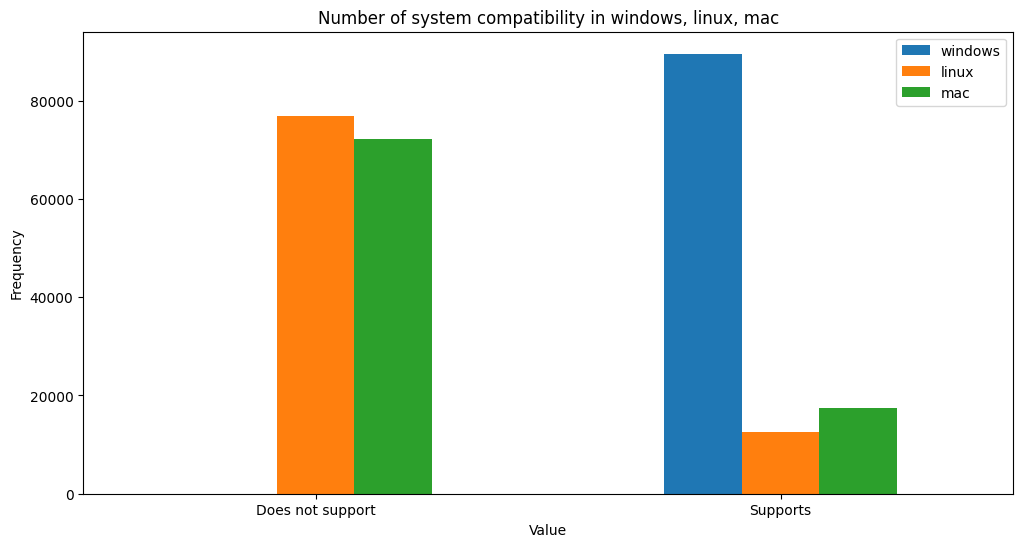

In [20]:
# Count the number of occurences of 0 and 1 in each analyzed column
windows_counts = df_games['windows'].value_counts()
linux_counts = df_games['linux'].value_counts()
mac_counts = df_games['mac'].value_counts()

# Combine the counts into a single DataFrame
road_type = pd.DataFrame({
    'windows': windows_counts,
    'linux': linux_counts,
    'mac': mac_counts
})

road_type.plot(kind='bar', figsize=(12, 6))
plt.title('Number of system compatibility in windows, linux, mac')
plt.xlabel('Value')
plt.xticks([0, 1], ['Does not support', 'Supports'])
plt.ylabel('Frequency')
plt.xticks(rotation=0)

plt.show()

In [21]:
df_games = df_games.drop(['windows'], axis=1)

### Year and Month extraction
while *release_date* can be an interesting attribute per se, we are not interested in analyzing the exact date of the game release. from *release_date*, the three attributes are exracted, and later the *release_date* and *day* are dropped. This also simplifies the attribute usage

In [22]:
df_games[['year', 'month', 'day']] = df_games['release_date'].str.split('-', expand=True).astype(int)

In [23]:
df_games = df_games.drop(['release_date', 'day'], axis=1)

### *metacritic_score* and *user_score*
Following are two pie charts on the percentage of the non-0 value in the rispective scores. While in both attribute, the 0-value is dominant, in user_score this value is very scarse, so much that the slice is almost "inperceivable", therefore it is dropped. metascritic_score might be used to analyze the subset of games where its value is not 0

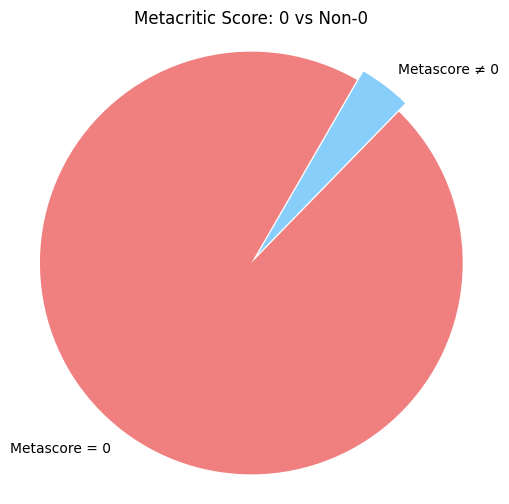

In [24]:
metascore_counts = df_games['metacritic_score'].value_counts()

zero_count = metascore_counts.get(0, 0)
nonzero_count = metascore_counts.sum() - zero_count

plt.figure(figsize=(6, 6))
plt.pie([zero_count, nonzero_count], labels=['Metascore = 0', 'Metascore ≠ 0'], startangle=60, colors=['lightcoral', 'lightskyblue'], explode=(0.05, 0))
plt.title('Metacritic Score: 0 vs Non-0')
plt.axis('equal')
plt.show()

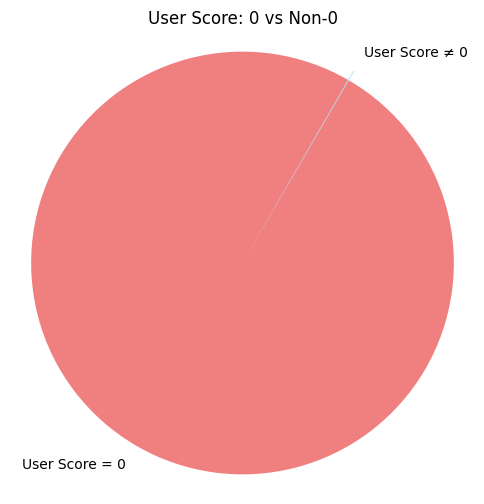

In [25]:
userscore_counts = df_games['user_score'].value_counts()

zero_count = userscore_counts.get(0, 0)
nonzero_count = userscore_counts.sum() - zero_count

plt.figure(figsize=(6, 6))
plt.pie([zero_count, nonzero_count], labels=['User Score = 0', 'User Score ≠ 0'], startangle=60, colors=['lightcoral', 'lightskyblue'], explode=(0.05, 0))
plt.title('User Score: 0 vs Non-0')
plt.axis('equal')
plt.show()

In [26]:
df_games = df_games.drop(['user_score'], axis=1)

### *estimated_owners* transformation
The dataset does not provide a precise value for the number estimated owners of each game, instead, it provides a numeric range, within which, the number occurs.<br>
To simplify the following analysis, we decided to take the midpoint from these values as approximation

In [27]:
def extract_midpoint(range_str):
    if range_str == 'missing':
        return 0
    parts = range_str.split(' - ')
    lower = int(parts[0])
    upper = int(parts[1])
    return lower + (upper - lower) / 2

df_games['estimated_owners'] = df_games['estimated_owners'].apply(extract_midpoint).astype(int)

### *peak_ccu*
peak_ccu mean the peak number of concurrent users for a game. This attribute can be interesting to analyze, but large part of its rows has 0 values. An additional dataset is merged with the sole purpose of updating the said attribute

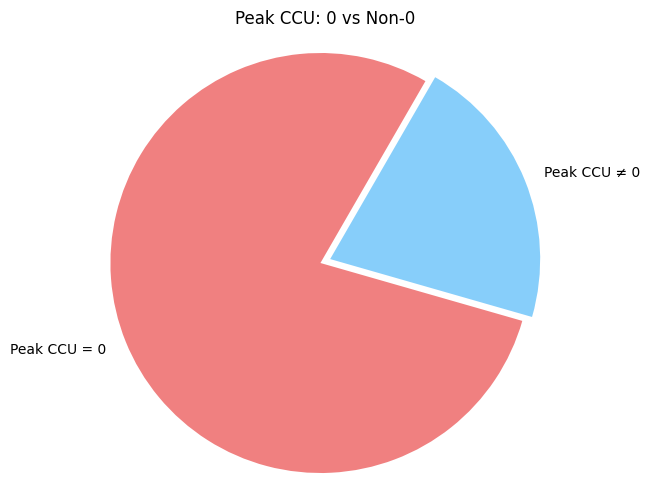

In [28]:
ccu_counts = df_games['peak_ccu'].value_counts()

zero_count = ccu_counts.get(0, 0)
nonzero_count = ccu_counts.sum() - zero_count

plt.figure(figsize=(6, 6))
plt.pie([zero_count, nonzero_count], labels=['Peak CCU = 0', 'Peak CCU ≠ 0'], startangle=60, colors=['lightcoral', 'lightskyblue'], explode=(0.05, 0))
plt.title('Peak CCU: 0 vs Non-0')
plt.axis('equal')
plt.show()

In [29]:
df_playtime = pd.read_csv("datasets/most_played_games.csv")

# Normalize the column names in the playtime dataset to ensure consistent keys for merging and analysis
df_playtime.columns = [normalize_key(col) for col in df_playtime.columns]

df_playtime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6290 entries, 0 to 6289
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             6290 non-null   int64 
 1   name           6290 non-null   object
 2   current        6290 non-null   object
 3   24th_peak      6290 non-null   object
 4   all_time_peak  6290 non-null   object
dtypes: int64(1), object(4)
memory usage: 245.8+ KB


In [30]:
# Normalize the 'name' column in both datasets to ensure consistent keys for merging
df_playtime['name'] = df_playtime['name'].apply(normalize_key)
df_games['name'] = df_games['name'].apply(normalize_key)

In [31]:
# Convert df_playtime all_time_peak to numeric (remove commas) and build a mapping by name (use max if duplicates)
df_playtime['all_time_peak_num'] = pd.to_numeric(
    df_playtime['all_time_peak'].astype(str).str.replace(r'[,\s]', '', regex=True),
    errors='coerce'
)
playtime_map = df_playtime.groupby('name')['all_time_peak_num'].max().dropna().astype(int).to_dict()
df_playtime = df_playtime.drop(['all_time_peak'], axis=1)

# Map and replace only where a match exists
mapped = df_games['name'].map(playtime_map)
replaced_count = mapped.notna().sum()
df_games.loc[mapped.notna(), 'peak_ccu'] = mapped[mapped.notna()].astype(int)

print(f"Replaced peak_ccu for {replaced_count} games.")

Replaced peak_ccu for 5773 games.
